# FEM for submerged tunnel as 2D beams Dynamic

In [18]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

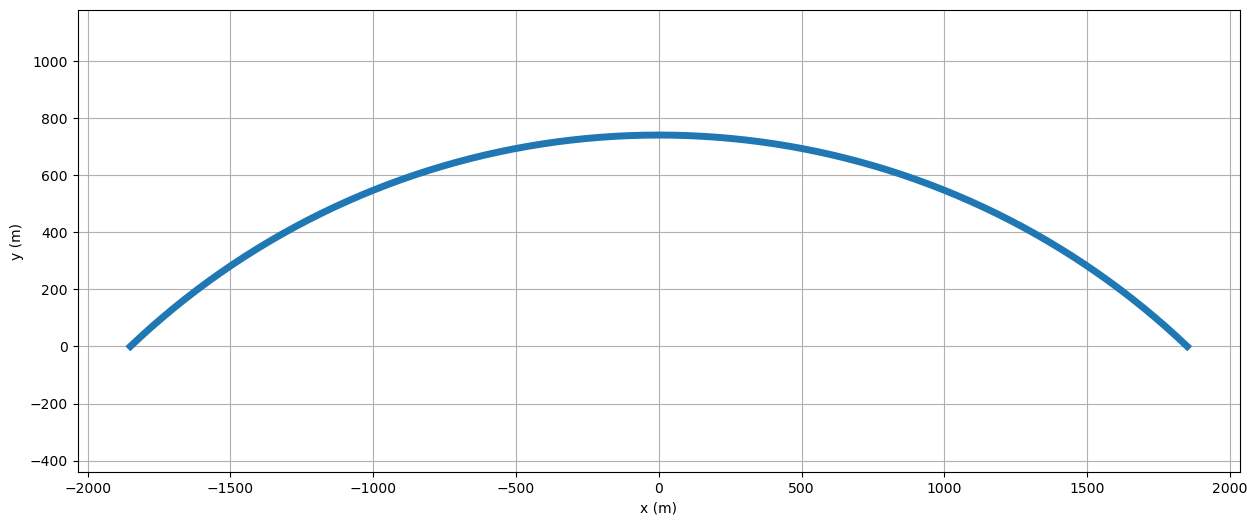

3700.4984716856134 740.0468957632836


In [35]:
TunRad = 2683 #m
TunAng = (133.6, 46.4) #deg
dth = 1.09 #deg
TunCX = TunRad*np.cos( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunRad*np.sin( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunCY - min(TunCY)

# numX = 100
# TunCX = np.arange(0, 100+100/numX, 100/numX)
# TunCY = 0.0*TunCX

plt.plot(TunCX, TunCY, lw=5)
plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()
print(TunCX[-1]-TunCX[0], max(TunCY))

## Properties of Beam

In [20]:
Beam_m = 100                  # [kg/m]
Beam_EI = 1e7                 # [N.m2]
Beam_EA = 1e6                 # [N]

## Mesh setup

In [21]:
NodeC = [ [x,y] for x,y in zip(TunCX, TunCY) ]
nNode = len(NodeC)

# Define elements (and their properties
#             NodeLeft    NodeRight          m         EA        EI
Ele = [ [n1, n2, Beam_m, Beam_EA, Beam_EI] 
           for n1,n2 in zip(range(0,nNode-1), range(1,nNode)) ]
nEle = len(Ele)

print("Number of nodes = ",nNode, ", Ranging from 0 to ",nNode-1)
print("Number of elements = ",nEle, ", Ranging from 0 to ",nEle-1)
# print(NodeC)
print(Ele)

Number of nodes =  81 , Ranging from 0 to  80
Number of elements =  80 , Ranging from 0 to  79
[[0, 1, 100, 1000000.0, 10000000.0], [1, 2, 100, 1000000.0, 10000000.0], [2, 3, 100, 1000000.0, 10000000.0], [3, 4, 100, 1000000.0, 10000000.0], [4, 5, 100, 1000000.0, 10000000.0], [5, 6, 100, 1000000.0, 10000000.0], [6, 7, 100, 1000000.0, 10000000.0], [7, 8, 100, 1000000.0, 10000000.0], [8, 9, 100, 1000000.0, 10000000.0], [9, 10, 100, 1000000.0, 10000000.0], [10, 11, 100, 1000000.0, 10000000.0], [11, 12, 100, 1000000.0, 10000000.0], [12, 13, 100, 1000000.0, 10000000.0], [13, 14, 100, 1000000.0, 10000000.0], [14, 15, 100, 1000000.0, 10000000.0], [15, 16, 100, 1000000.0, 10000000.0], [16, 17, 100, 1000000.0, 10000000.0], [17, 18, 100, 1000000.0, 10000000.0], [18, 19, 100, 1000000.0, 10000000.0], [19, 20, 100, 1000000.0, 10000000.0], [20, 21, 100, 1000000.0, 10000000.0], [21, 22, 100, 1000000.0, 10000000.0], [22, 23, 100, 1000000.0, 10000000.0], [23, 24, 100, 1000000.0, 10000000.0], [24, 25, 10

Listing the nodes and elements. <br>
Plot the mesh setup for reference.

Nodes
0 	 -1850.2492358428015 	 9.549694368615746e-12
1 	 -1812.9537456373093 	 34.845600429572414
2 	 -1775.002138331596 	 68.97542553720746
3 	 -1736.4081488036718 	 102.37712356714746
4 	 -1697.1857444129118 	 135.03860627648714
5 	 -1657.3491199451976 	 166.94805330997747
6 	 -1616.9126924757536 	 198.09391647787038
7 	 -1575.8910961515326 	 228.46492393527092
8 	 -1534.2991768950478 	 258.05008426146946
9 	 -1492.151987031556 	 286.8386904377951
10 	 -1449.4647798415463 	 314.8203237225414
11 	 -1406.2530040405015 	 341.98485742155685
12 	 -1362.5322981879267 	 368.3224605531525
13 	 -1318.31848502768 	 393.8236014059778
14 	 -1273.6275657616409 	 418.47905098859906
15 	 -1228.4757142587919 	 442.2798863695159
16 	 -1182.8792712018187 	 465.2174939064164
17 	 -1136.8547381733267 	 487.28357236349825
18 	 -1090.418771683845 	 508.470135915725
19 	 -1043.5881771437448 	 528.7695170389386
20 	 -996.3799027812768 	 548.174369284776
21 	 -948.8110335089252 	 566.6776699393824
22 	 -900

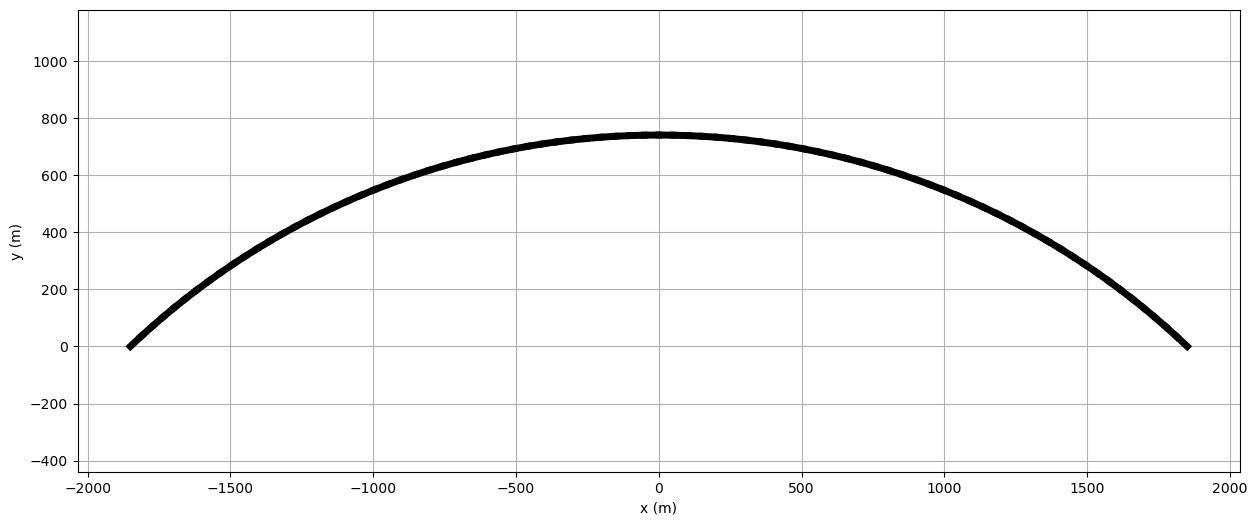

In [36]:
print("Nodes")
for iNode in range(0, nNode):
    print(iNode, "\t", NodeC[iNode][0], "\t", NodeC[iNode][1])

plt.figure()
print("Elements")
for iEle in range(0, nEle):
    n1, n2, m, EA, EI = Ele[iEle]
    print(iEle, n1, n2, m, EA, EI)
    plt.plot( [NodeC[n1][0], NodeC[n2][0]], [NodeC[n1][1], NodeC[n2][1]], lw=5, color='k')

plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.show()
pass

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

$$ M = \frac{mL}{420} \begin{bmatrix} 140 & 0 & 0 & 70 & 0 & 0 \\ 0 & 156 & 22L & 0 & 54 & -13L \\ 0 & 22L & 4L^2 & 0 & 13L & -3L^2 \\ 70 & 0 & 0 & 140 & 0 & 0 \\ 0 & 54 & 13L & 0 & 156 & -22L \\ 0 & -13L & -3L^2 & 0 & -22L & 4L^2 \end{bmatrix} $$
$$ \quad K = \begin{bmatrix} \frac{EA}{L} & 0 & 0 & \frac{-EA}{L} &  0 & 0 \\ 0 & \frac{12EI}{L^3} & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & \frac{6EI}{L^2} \\ 0 & \frac{6EI}{L^2} & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & \frac{2EI}{L} \\ \frac{-EA}{L} & 0 & 0 & \frac{EA}{L} & 0 & 0 \\ 0 & \frac{-12EI}{L^3} & \frac{-6EI}{L^2} & 0 & \frac{12EI}{L^3} & \frac{-6EI}{L^2} \\ 0 & \frac{6EI}{L^2} & \frac{2EI}{L} & 0 & \frac{-6EI}{L^2} & \frac{4EI}{L} \end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [23]:
LDOF = 3
nDof = LDOF*nNode  #3 dof per node
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)

from BeamMatrices import Beam2DMatrices

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1, n2, m, EA, EI = Ele[iEle]
    
    n1dof = LDOF*n1 + np.arange(0,LDOF)
    n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
    # Calculate elemental matrices
    Me, Ke, Qe = Beam2DMatrices(m, EA, EI, (NodeC[n1], NodeC[n2]) )
    
    indexes = np.append(n1dof, n2dof)
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            #print(ij)
            M[ij] = M[ij] + Me[i,j]
            K[ij] = K[ij] + Ke[i,j]
            Q[ij] = Q[ij] + Qe[i,j]

# Reshape the global matrix from a 1-dimensional array to a 2-dimensional array
M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

exeTime[1] = time.time()
print("Execution time = ", exeTime[1] - exeTime[0], "s")

Execution time =  0.009316682815551758 s


That completes the filling of the matrices. Let's have a look at the matrices' structure.

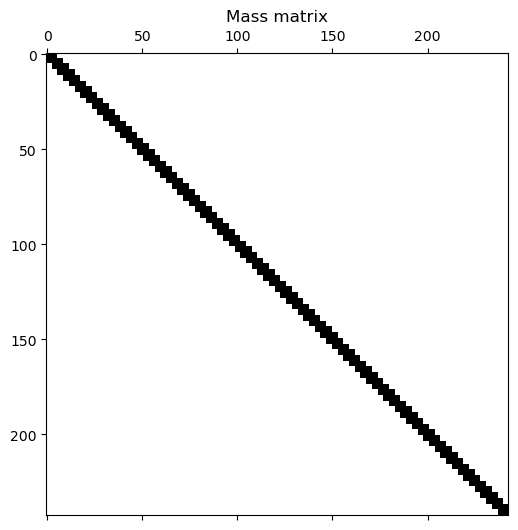

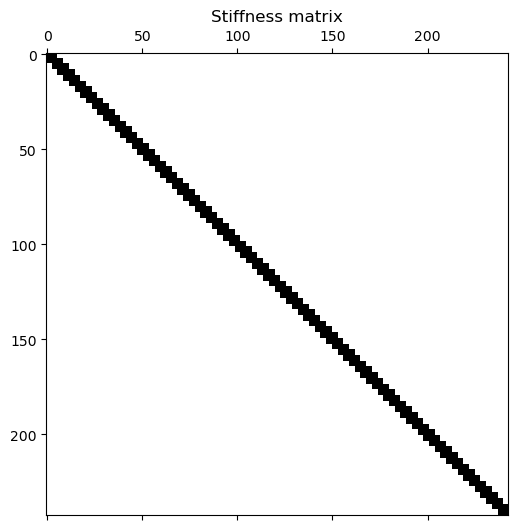

In [ ]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
plt.show()
pass

## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[  0   1   2 240 241 242]
[  3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56
  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74
  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92
  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110
 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128
 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146
 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164
 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218
 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
 237 238 239]


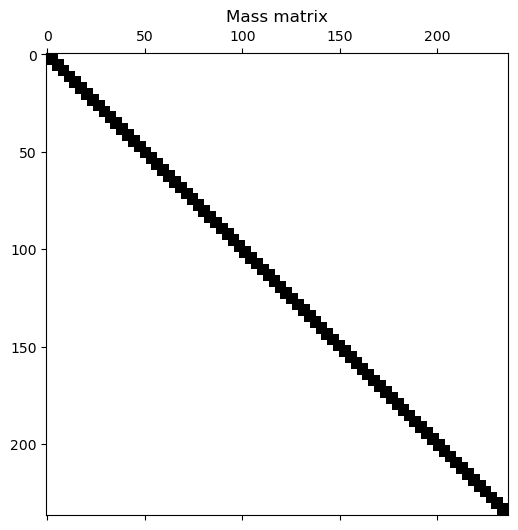

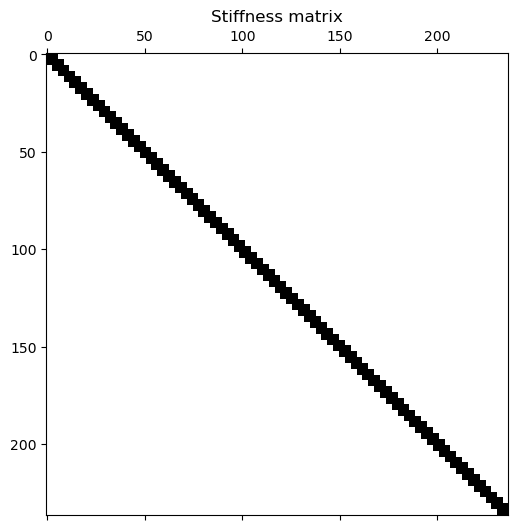

In [25]:
NodesClamp = (0, nNode-1)

# Prescribed dofs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Free dofs
DofsF = np.arange(0, nDof)       # free DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs from the free DOFs array

print(DofsP)
print(DofsF)

M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

plt.figure()
plt.spy(M_FF)
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF)
plt.title("Stiffness matrix")
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [26]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))
print(f)

237
[1.07952791e+00 1.07765998e+00 1.07456185e+00 1.07025582e+00
 1.06477243e+00 1.05814984e+00 1.05043303e+00 1.04167294e+00
 1.03192553e+00 1.02125073e+00 1.00971151e+00 9.97372836e-01
 9.84300763e-01 9.70561554e-01 9.69259243e-01 9.67595926e-01
 9.64839306e-01 9.61012320e-01 9.56221833e-01 9.56145389e-01
 9.50280485e-01 9.41343118e-01 9.43460567e-01 9.35738341e-01
 9.25990540e-01 9.27170625e-01 9.17816902e-01 9.10223978e-01
 9.07740608e-01 8.94100189e-01 8.97005971e-01 8.85677946e-01
 8.77673664e-01 8.73821131e-01 8.60993284e-01 8.61501178e-01
 8.48774464e-01 8.44111973e-01 8.09906117e-01 8.35705200e-01
 8.27068964e-01 8.22348654e-01 8.08758258e-01 7.92660509e-01
 7.94984090e-01 7.75365811e-01 7.81072691e-01 7.58052471e-01
 7.67066986e-01 7.23472780e-01 7.53006239e-01 7.40748325e-01
 7.38925645e-01 7.24862409e-01 7.10836823e-01 7.06256056e-01
 6.96880375e-01 6.89111417e-01 6.04989512e-01 6.83015038e-01
 6.15671657e-01 6.21561194e-01 6.72056263e-01 6.69260847e-01
 6.28828793e-01 6.55

In [27]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

237


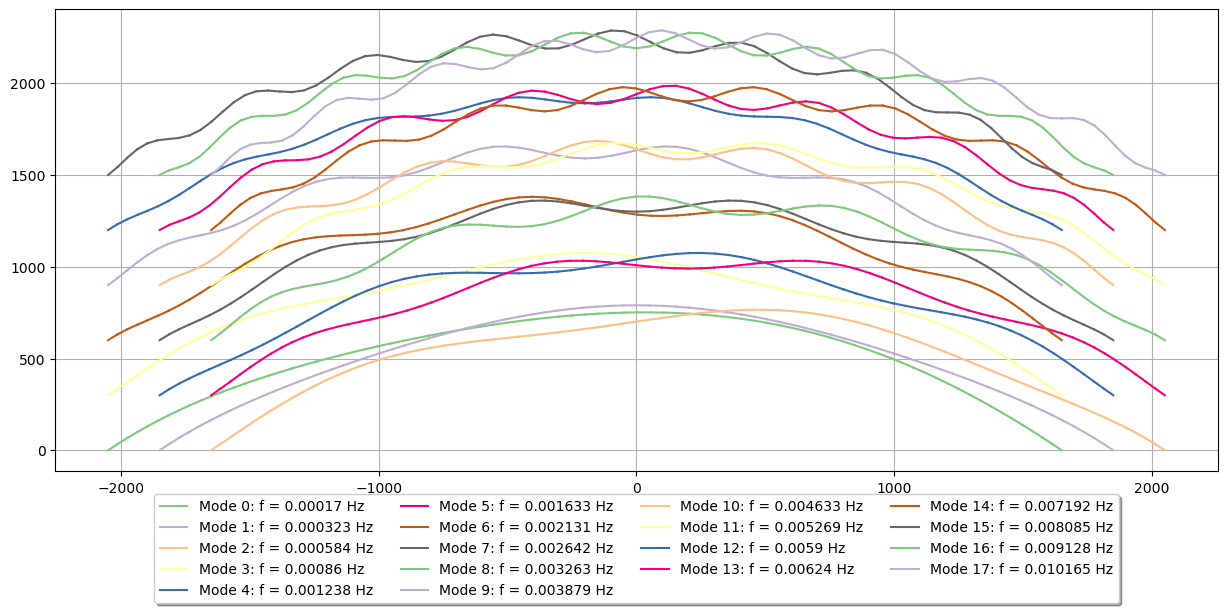

In [28]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

plt.figure()
cmap = plt.colormaps.get_cmap('Accent')
cmap = cmap.colors
nCmap = len(cmap)

nCol = 2
nRow = int(np.floor(nMode/nCol))+1
for iMode in np.arange(0, 0+18):    
#for iMode in np.arange(nMode-1, nMode-19, -1):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 10
    MaxTranslationx = np.max(np.abs(Shape[0::3]))
    MaxTranslationy = np.max(np.abs(Shape[1::3]))
    Shape[0::3] = Shape[0::3]/MaxTranslationx*1
    Shape[1::3] = Shape[1::3]/MaxTranslationy*50

    # Get the deformed shape
    DisplacedNode = ([i[0] + (iMode%3-1)*200 for i in NodeC] + Shape[0::3], 
                     [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::3])
    for iElem in np.arange(0, nEle):
        NodeLeft = Ele[iElem][0]
        NodeRight = Ele[iElem][1]
        if(iElem == 0):
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap], 
                     label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
        else:
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap])
    #plt.title("Mode "+str(iMode)+": f = "+str(f[iMode])+" Hz")
    #plt.axis('equal')
    plt.grid('on')
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
          ncol=4, fancybox=True, shadow=True)
    #print("Mode ", iMode, "f = ", f[iMode])
pass